In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/clarra/dataset-all-split/dataset_with_split.csv


# M3-v2-CE — CABiLSTM-IndoBERT + Cross Entropy + Sqrt-based Class Weighting (Multilabel Wide Format)

**Ablation study: M3-v2 tanpa Focal Loss — hanya Sqrt-based Class Weighting + standard BCE.**

## Purpose (Ablation Study)
Memisahkan kontribusi **Focal Loss** dari **Class Weighting** dalam menangani class imbalance.

| | M3-v2 | **M3-v2-CE** |
|---|---|---|
| Architecture | CABiLSTM + Partial Unfreeze | **Identik** |
| Loss | Focal BCE (γ=2.0) + Sqrt weight | **Masked BCE + Sqrt weight** |
| Focal modulation | ✅ `(1-p_t)^γ` | ❌ Dihapus |
| Class weighting | Sqrt-normalized `pos_weight` | **Identik** |

Jika M3-v2-CE ≈ M3-v2 → Focal Loss tidak signifikan, class weighting sudah cukup.
Jika M3-v2-CE < M3-v2 → Focal Loss berkontribusi nyata terhadap minority class recovery.

## Architecture (identical to M3-v2):
```
Input: [CLS] review_text [SEP]
  │
  ▼
IndoBERT (layers 8–11 trainable, lr=2e-5)
  │
  ▼
CABiLSTM (lr=5e-4) → Masked Mean Pooling
  │
  ▼
MLP: 1024 → 512 → 15 outputs
```

**References**: Mahajan et al. (2018) ECCV; He et al. (2025).

---
## Section 1: Setup & Imports

In [2]:
import os, json, random, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, classification_report, confusion_matrix,
)

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')

PyTorch : 2.10.0+cu128
CUDA    : True


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


---
## Section 2: Configuration & Constants

In [4]:
CONFIG = {
    # Model
    'model_name'          : 'indobenchmark/indobert-base-p1',
    'num_outputs'         : 15,        # 5 aspects × 3 sentiments
    'dropout'             : 0.3,
    # Tokenization
    'max_length'          : 128,
    # Training
    'batch_size'          : 16,
    'weight_decay'        : 0.01,
    'epochs'              : 10,
    'patience'            : 3,
    'warmup_ratio'        : 0.1,
    'grad_clip'           : 1.0,
    # Partial unfreeze (same as M3-v2)
    'num_unfrozen_layers' : 4,
    'lr_bert'             : 2e-5,
    'lr_cabilstm'         : 5e-4,
    # CABiLSTM architecture (He et al., 2025)
    'bilstm_hidden'       : 384,
    'attn_heads'          : 8,
    'conv_kernel'         : 5,
    'mlp_hidden_1'        : 1024,
    'mlp_hidden_2'        : 512,
    # Class Weighting — Sqrt-normalized (no Focal Loss)
    'weight_strategy'     : 'sqrt_normalized',
    'focal_gamma'         : None,      # Ablation: no Focal Loss
    'seed'                : SEED,
}

ASPECTS    = ['PIGMENTATION', 'LONGEVITY', 'TEXTURE', 'HYDRATION', 'PRICE']
SENTIMENTS = ['negative', 'neutral', 'positive']   # index 0, 1, 2
SENT2ID    = {s: i for i, s in enumerate(SENTIMENTS)}
ID2SENT    = {i: s for s, i in SENT2ID.items()}

DATA_PATH           = '/kaggle/input/datasets/clarra/dataset-all-split/dataset_with_split.csv'
OUTPUT_DIR          = '/kaggle/working'
BEST_MODEL_PATH     = f'{OUTPUT_DIR}/m3v2ce_best.pt'
PREDICTIONS_PATH    = f'{OUTPUT_DIR}/m3v2ce_predictions.csv'
METRICS_PATH        = f'{OUTPUT_DIR}/m3v2ce_metrics.json'
LOSS_PLOT_PATH      = f'{OUTPUT_DIR}/m3v2ce_loss_convergence.png'
CM_PLOT_PATH        = f'{OUTPUT_DIR}/m3v2ce_confusion_matrix.png'
PERASPECT_PLOT_PATH = f'{OUTPUT_DIR}/m3v2ce_per_aspect_results.png'

assert os.path.exists(DATA_PATH), f'Dataset not found: {DATA_PATH}'
print('Config loaded.')
for k, v in CONFIG.items():
    print(f'  {k:<22} {v}')

Config loaded.
  model_name             indobenchmark/indobert-base-p1
  num_outputs            15
  dropout                0.3
  max_length             128
  batch_size             16
  weight_decay           0.01
  epochs                 10
  patience               3
  warmup_ratio           0.1
  grad_clip              1.0
  num_unfrozen_layers    4
  lr_bert                2e-05
  lr_cabilstm            0.0005
  bilstm_hidden          384
  attn_heads             8
  conv_kernel            5
  mlp_hidden_1           1024
  mlp_hidden_2           512
  weight_strategy        sqrt_normalized
  focal_gamma            None
  seed                   42


---
## Section 3: Load Data & EDA

In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Total rows : {len(df)}')
print('Split distribution:')
print(df['split'].value_counts().to_string())
display(df.head(3))

Total rows : 1098
Split distribution:
split
train    998
val       50
test      50


,review_id,review_text,product_name,product_brand,PIGMENTATION,LONGEVITY,TEXTURE,HYDRATION,PRICE,is_synthetic,source_fase,method,split
0,388,"Aku kira bakalan aroma strawberrynya kuat, ter...",24H Melt-In Moisture,Nivea,no_aspect,no_aspect,no_aspect,positive,no_aspect,False,NaN,NaN,train
1,334,Beli produk ini tuh awalnya karena IKON hahaha...,24H Melt-In Moisture,Nivea,positive,no_aspect,no_aspect,positive,no_aspect,False,NaN,NaN,train
2,142,My favorit lip balm!! enggak bikin bibir kerin...,24H Melt-In Moisture,Nivea,neutral,no_aspect,positive,positive,no_aspect,False,NaN,NaN,train


In [6]:
train_df = df[df['split'] == 'train']
print('Label distribution per aspect (train set):')
print(f'{"Aspect":<14} {"positive":>9} {"negative":>9} {"neutral":>9} {"no_aspect":>10} {"imb_ratio":>10}')
print('-' * 65)
for asp in ASPECTS:
    counts = train_df[asp].value_counts()
    pos, neg, neu, noa = (counts.get(k, 0) for k in ['positive', 'negative', 'neutral', 'no_aspect'])
    sents = [c for c in [pos, neg, neu] if c > 0]
    ratio = max(sents) / min(sents) if sents else 0
    print(f'{asp:<14} {pos:>9} {neg:>9} {neu:>9} {noa:>10} {ratio:>9.1f}:1')

Label distribution per aspect (train set):
Aspect          positive  negative   neutral  no_aspect  imb_ratio
-----------------------------------------------------------------
PIGMENTATION         377        98       172        351       3.8:1
LONGEVITY             93       193        40        672       4.8:1
TEXTURE              272       114        41        571       6.6:1
HYDRATION            584       176        85        153       6.9:1
PRICE                252        20        11        715      22.9:1


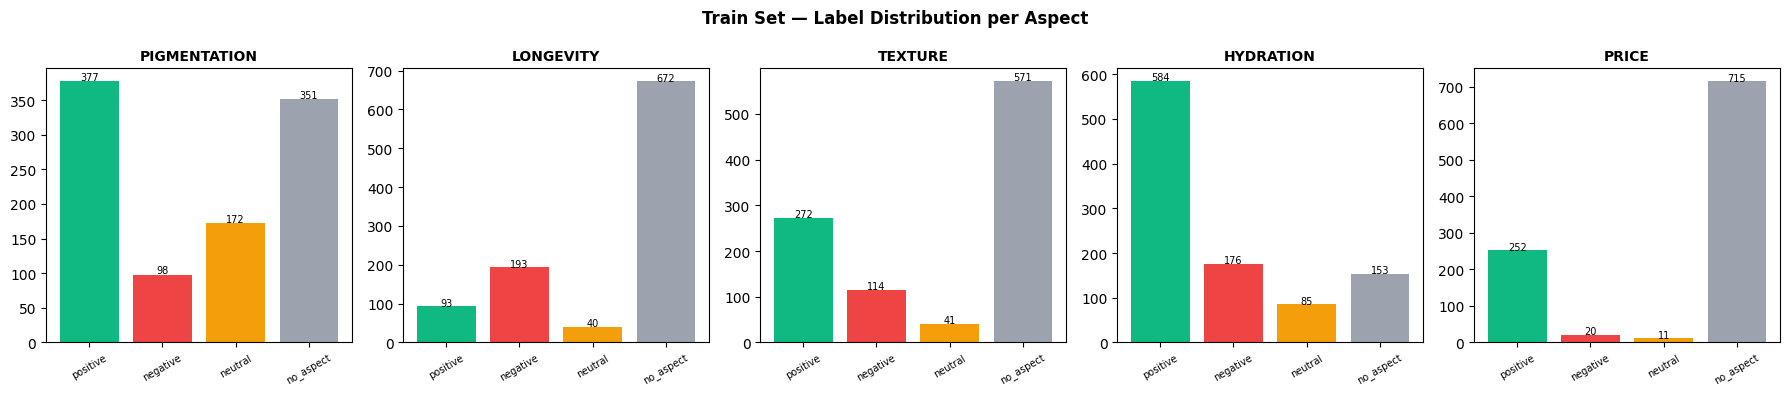

In [7]:
SENT_COLORS = {'negative': '#ef4444', 'neutral': '#f59e0b',
               'positive': '#10b981', 'no_aspect': '#9ca3af'}

fig, axes = plt.subplots(1, len(ASPECTS), figsize=(18, 4))
for ax, asp in zip(axes, ASPECTS):
    counts = train_df[asp].value_counts().reindex(
        ['positive', 'negative', 'neutral', 'no_aspect'], fill_value=0
    )
    bars = ax.bar(counts.index, counts.values,
                  color=[SENT_COLORS[l] for l in counts.index])
    ax.set_title(asp, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(v), ha='center', fontsize=7)
plt.suptitle('Train Set — Label Distribution per Aspect', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4: Tokenizer & Dataset

In [8]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'Tokenizer : {CONFIG["model_name"]}')
print(f'Vocab size: {tokenizer.vocab_size:,}')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer : indobenchmark/indobert-base-p1
Vocab size: 30,521


In [9]:
class ABSADataset(Dataset):
    """
    Multilabel ABSA dataset — wide format.

    Input : [CLS] review_text [SEP]
    labels: float tensor (15,)  — one-hot per active (aspect, sentiment) slot
    mask  : float tensor (15,)  — 1.0 for slots where aspect != no_aspect

    Flat layout: [pig_neg, pig_neu, pig_pos, lon_neg, ..., pri_pos]
    """

    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 128):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        enc = self.tokenizer(
            str(row['review_text']),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

        labels = torch.zeros(15, dtype=torch.float)
        mask   = torch.zeros(15, dtype=torch.float)

        for asp_idx, asp in enumerate(ASPECTS):
            val  = row[asp]
            base = asp_idx * 3
            if val != 'no_aspect':
                labels[base + SENT2ID[val]] = 1.0
                mask[base : base + 3]       = 1.0

        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'labels'        : labels,
            'mask'          : mask,
            'review_id'     : str(row['review_id']),
        }

In [10]:
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'  ].reset_index(drop=True)
test_df  = df[df['split'] == 'test' ].reset_index(drop=True)

train_ds = ABSADataset(train_df, tokenizer, CONFIG['max_length'])
val_ds   = ABSADataset(val_df,   tokenizer, CONFIG['max_length'])
test_ds  = ABSADataset(test_df,  tokenizer, CONFIG['max_length'])

print(f'Train : {len(train_ds)} reviews')
print(f'Val   : {len(val_ds)} reviews')
print(f'Test  : {len(test_ds)} reviews')

s = train_ds[0]
print(f'\nSample 0 active aspects: '
      f'{[(ASPECTS[i], SENTIMENTS[j]) for i in range(5) for j in range(3) if s["labels"][i*3+j] == 1.0]}')

Train : 998 reviews
Val   : 50 reviews
Test  : 50 reviews

Sample 0 active aspects: [('HYDRATION', 'positive')]


---
## Section 5: DataLoader

In [11]:
def collate_fn(batch):
    return {
        'input_ids'     : torch.stack([b['input_ids']      for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'token_type_ids': torch.stack([b['token_type_ids'] for b in batch]),
        'labels'        : torch.stack([b['labels']         for b in batch]),
        'mask'          : torch.stack([b['mask']           for b in batch]),
        'review_id'     : [b['review_id'] for b in batch],
    }

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

b = next(iter(train_loader))
print('\nBatch shapes:')
for k in ['input_ids', 'attention_mask', 'token_type_ids', 'labels', 'mask']:
    print(f'  {k:<16}: {b[k].shape}  dtype={b[k].dtype}')

Train batches: 63
Val   batches: 4
Test  batches: 4

Batch shapes:
  input_ids       : torch.Size([16, 128])  dtype=torch.int64
  attention_mask  : torch.Size([16, 128])  dtype=torch.int64
  token_type_ids  : torch.Size([16, 128])  dtype=torch.int64
  labels          : torch.Size([16, 15])  dtype=torch.float32
  mask            : torch.Size([16, 15])  dtype=torch.float32


---
## Section 6: Model Definition — CABiLSTM-IndoBERT (Partial Unfreeze)

Arsitektur identik dengan M3-v2.

In [12]:
class CABiLSTMCore(nn.Module):
    """
    CABiLSTM deep implicit feature extraction layer (He et al., 2025 Section 3.3).

    Pipeline:
      1. Dual-layer BiLSTM → preserve outputs {V, F1, B1, F2, B2}
      2. MHSA on each of 5 feature groups independently
      3. Channel-wise concat {A1..A5} → Conv2d (5→1) → ReLU

    Input : x  [B, L, hidden_dim]
    Output: Co [B, L, hidden_dim]
    """

    def __init__(self, hidden_dim: int = 768, bilstm_hidden: int = 384,
                 num_heads: int = 8, conv_kernel: int = 5):
        super().__init__()

        self.bilstm1 = nn.LSTM(hidden_dim, bilstm_hidden, num_layers=1,
                               bidirectional=True, batch_first=True)
        self.bilstm2 = nn.LSTM(hidden_dim, bilstm_hidden, num_layers=1,
                               bidirectional=True, batch_first=True)

        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads,
            dropout=0.0, batch_first=True,
        )

        pad = conv_kernel // 2
        self.conv = nn.Conv2d(in_channels=5, out_channels=1,
                              kernel_size=conv_kernel, padding=pad)

    def _split_bidirectional(self, out: torch.Tensor) -> tuple:
        """Split BiLSTM output into forward/backward, each repeated to full hidden_dim."""
        half = out.size(-1) // 2
        fwd, bwd = out[..., :half], out[..., half:]
        return torch.cat([fwd, fwd], dim=-1), torch.cat([bwd, bwd], dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out1, _ = self.bilstm1(x)
        F1, B1  = self._split_bidirectional(out1)

        out2, _ = self.bilstm2(out1)
        F2, B2  = self._split_bidirectional(out2)

        attended = [self.attention(fg, fg, fg)[0] for fg in [x, F1, B1, F2, B2]]

        Ao = torch.stack(attended, dim=1)        # [B, 5, L, 768]
        Co = F.relu(self.conv(Ao).squeeze(1))    # [B, L, 768]
        return Co

In [13]:
class M3v2CE_CABiLSTM_IndoBERT(nn.Module):
    """
    M3-v2-CE: CABiLSTM-IndoBERT with partial unfreeze — architecture identical to M3-v2.

    The only difference from M3-v2 is the loss function:
    masked_weighted_bce_loss (no focal modulation) instead of masked_focal_bce_loss.
    This isolates the contribution of Focal Loss in the ablation study.
    """

    def __init__(self, config: dict):
        super().__init__()

        self.bert = AutoModel.from_pretrained(config['model_name'])
        self._apply_partial_freeze(config['num_unfrozen_layers'])

        hidden_dim = self.bert.config.hidden_size

        self.cabilstm = CABiLSTMCore(
            hidden_dim    = hidden_dim,
            bilstm_hidden = config['bilstm_hidden'],
            num_heads     = config['attn_heads'],
            conv_kernel   = config['conv_kernel'],
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim,             config['mlp_hidden_1']),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(config['mlp_hidden_1'], config['mlp_hidden_2']),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(config['mlp_hidden_2'], config['num_outputs']),
        )
        self._init_classifier_weights()

    def _apply_partial_freeze(self, num_unfrozen: int):
        n_total  = len(self.bert.encoder.layer)
        n_frozen = n_total - num_unfrozen

        for p in self.bert.embeddings.parameters():
            p.requires_grad = False

        for i, layer in enumerate(self.bert.encoder.layer):
            for p in layer.parameters():
                p.requires_grad = (i >= n_frozen)

        print(f'BERT freeze: embeddings + layers 0–{n_frozen-1} frozen | '
              f'layers {n_frozen}–{n_total-1} trainable')

    def _init_classifier_weights(self):
        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def get_param_groups(self, lr_bert: float, lr_cabilstm: float,
                         weight_decay: float) -> list:
        """
        Differential LR parameter groups:
          - BERT unfrozen layers : lr_bert
          - CABiLSTM + MLP      : lr_cabilstm
        Each split into decay / no-decay for AdamW.
        """
        no_decay    = {'bias', 'LayerNorm.weight'}
        bert_decay,  bert_nodecay  = [], []
        other_decay, other_nodecay = [], []

        for name, param in self.named_parameters():
            if not param.requires_grad:
                continue
            is_bert    = name.startswith('bert.')
            is_nodecay = any(nd in name for nd in no_decay)

            if is_bert:
                (bert_nodecay if is_nodecay else bert_decay).append(param)
            else:
                (other_nodecay if is_nodecay else other_decay).append(param)

        return [
            {'params': bert_decay,   'lr': lr_bert,    'weight_decay': weight_decay},
            {'params': bert_nodecay, 'lr': lr_bert,    'weight_decay': 0.0},
            {'params': other_decay,  'lr': lr_cabilstm,'weight_decay': weight_decay},
            {'params': other_nodecay,'lr': lr_cabilstm,'weight_decay': 0.0},
        ]

    def forward(self, input_ids, attention_mask, token_type_ids):
        V = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        ).last_hidden_state                              # [B, L, 768]

        Co = self.cabilstm(V)                           # [B, L, 768]

        mask_exp = attention_mask.unsqueeze(-1).float()
        M = (Co * mask_exp).sum(dim=1) / mask_exp.sum(dim=1).clamp(min=1)

        return self.classifier(M)                       # [B, 15]

In [14]:
model = M3v2CE_CABiLSTM_IndoBERT(CONFIG).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
bert_tr   = sum(p.numel() for n, p in model.named_parameters()
                if p.requires_grad and n.startswith('bert.'))

print(f'Total params          : {total:>14,}')
print(f'Trainable params      : {trainable:>14,}  ({100*trainable/total:.1f}%)')
print(f'  BERT unfrozen       : {bert_tr:>14,}  ({100*bert_tr/trainable:.1f}% of trainable)')
print(f'  CABiLSTM + MLP      : {trainable-bert_tr:>14,}  ({100*(trainable-bert_tr)/trainable:.1f}% of trainable)')
print(f'Frozen params         : {total-trainable:>14,}  ({100*(total-trainable)/total:.1f}%)')

model.eval()
with torch.no_grad():
    sample = next(iter(train_loader))
    logits = model(sample['input_ids'].to(device),
                   sample['attention_mask'].to(device),
                   sample['token_type_ids'].to(device))
    print(f'\nOutput shape : {logits.shape}  (expected: [{CONFIG["batch_size"]}, 15])')
    print(f'Any NaN      : {torch.isnan(logits).any().item()}')

if torch.cuda.is_available():
    print(f'GPU allocated: {torch.cuda.memory_allocated(device)/1e9:.2f} GB')
    torch.cuda.empty_cache()

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BERT freeze: embeddings + layers 0–7 frozen | layers 8–11 trainable
Total params          :    135,213,965
Trainable params      :     39,714,701  (29.4%)
  BERT unfrozen       :     28,942,080  (72.9% of trainable)
  CABiLSTM + MLP      :     10,772,621  (27.1% of trainable)
Frozen params         :     95,499,264  (70.6%)

Output shape : torch.Size([16, 15])  (expected: [16, 15])
Any NaN      : False
GPU allocated: 0.55 GB


---
## Section 7: Sqrt-based Class Weights + Masked BCE Loss (No Focal) + Optimizer

### Key Difference vs M3-v2
M3-v2 menggunakan **Focal BCE**: `loss = (1-p_t)^γ × weighted_bce`

M3-v2-CE menggunakan **plain weighted BCE** (no focal modulation): `loss = weighted_bce`

Class weights identik — sqrt-normalized (Mahajan et al., 2018).

In [15]:
# ── Compute sqrt-based class weights (identical to M3-v2) ────────────────────
sent_counts = {s: 0 for s in SENTIMENTS}
for asp in ASPECTS:
    counts = train_df[asp].value_counts()
    for s in SENTIMENTS:
        sent_counts[s] += counts.get(s, 0)

total_sent = sum(sent_counts.values())

raw_weights  = {s: math.sqrt(total_sent / max(sent_counts[s], 1)) for s in SENTIMENTS}
weight_mean  = sum(raw_weights.values()) / len(raw_weights)
norm_weights = {s: w / weight_mean for s, w in raw_weights.items()}

sent_weights = [norm_weights[s] for s in SENTIMENTS]
pos_weight   = torch.tensor(sent_weights * len(ASPECTS), dtype=torch.float).to(device)

print('Sentiment class counts (train set, all aspects):')
for s, cnt in sent_counts.items():
    print(f'  {s:<10}: {cnt:>5} ({100*cnt/total_sent:5.1f}%)')

print(f'\nSqrt-normalized weights (same as M3-v2, mean pre-norm={weight_mean:.4f}):')
for s in SENTIMENTS:
    print(f'  {s:<10}: raw={raw_weights[s]:.4f}  normalized={norm_weights[s]:.4f}')

print(f'\npos_weight shape: {pos_weight.shape}')

Sentiment class counts (train set, all aspects):
  negative  :   601 ( 23.8%)
  neutral   :   349 ( 13.8%)
  positive  :  1578 ( 62.4%)

Sqrt-normalized weights (same as M3-v2, mean pre-norm=2.0027):
  negative  : raw=2.0509  normalized=1.0241
  neutral   : raw=2.6914  normalized=1.3439
  positive  : raw=1.2657  normalized=0.6320

pos_weight shape: torch.Size([15])


In [16]:
def masked_weighted_bce_loss(
    logits    : torch.Tensor,
    labels    : torch.Tensor,
    mask      : torch.Tensor,
    pos_weight: torch.Tensor,
) -> torch.Tensor:
    """
    Weighted BCE loss with no_aspect masking — NO Focal modulation.

    Ablation counterpart of masked_focal_bce_loss (M3-v2).
    Isolates the contribution of class weighting alone (without focal focusing).

    Args:
        logits    : (B, 15) raw model output
        labels    : (B, 15) one-hot float targets
        mask      : (B, 15) 1.0 for active slots, 0.0 for no_aspect
        pos_weight: (15,)   sqrt-normalized per-slot class weight
    Returns:
        scalar mean weighted BCE over active slots
    """
    bce_weighted = F.binary_cross_entropy_with_logits(
        logits, labels, pos_weight=pos_weight, reduction='none'
    )  # (B, 15) — no focal term

    return (bce_weighted * mask).sum() / mask.sum().clamp(min=1.0)

In [17]:
# Differential LR optimizer (identical to M3-v2)
param_groups = model.get_param_groups(
    lr_bert     = CONFIG['lr_bert'],
    lr_cabilstm = CONFIG['lr_cabilstm'],
    weight_decay= CONFIG['weight_decay'],
)
optimizer = torch.optim.AdamW(param_groups)

total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(CONFIG['warmup_ratio'] * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

print('M3-v2-CE Setup Summary:')
print(f'  Optimizer       : AdamW differential LR (bert={CONFIG["lr_bert"]}, cabilstm={CONFIG["lr_cabilstm"]})')
print(f'  Total steps     : {total_steps}')
print(f'  Warmup steps    : {warmup_steps}')
print(f'  Loss            : Masked Weighted BCE (NO Focal — ablation study)')
print(f'  Weight strategy : sqrt(N_total/N_c), normalized to mean=1.0 (Mahajan et al., 2018)')
print(f'  BERT strategy   : Partial Unfreeze ({CONFIG["num_unfrozen_layers"]} top layers)')

print(f'\nParam groups:')
labels_pg = ['BERT decay', 'BERT no-decay', 'Other decay', 'Other no-decay']
for label, pg in zip(labels_pg, param_groups):
    n = sum(p.numel() for p in pg['params'])
    print(f'  {label:<20}: lr={pg["lr"]:.0e}  params={n:,}')

M3-v2-CE Setup Summary:
  Optimizer       : AdamW differential LR (bert=2e-05, cabilstm=0.0005)
  Total steps     : 630
  Warmup steps    : 63
  Loss            : Masked Weighted BCE (NO Focal — ablation study)
  Weight strategy : sqrt(N_total/N_c), normalized to mean=1.0 (Mahajan et al., 2018)
  BERT strategy   : Partial Unfreeze (4 top layers)

Param groups:
  BERT decay          : lr=0e+00  params=28,901,376
  BERT no-decay       : lr=0e+00  params=40,704
  Other decay         : lr=0e+00  params=10,755,709
  Other no-decay      : lr=0e+00  params=16,912


---
## Section 8: Metric Helpers

In [18]:
def preds_from_logits(logits: torch.Tensor, mask: torch.Tensor) -> np.ndarray:
    """(B,15) logits → (B,5) predicted sentiment index; -1 for no_aspect slots."""
    probs    = torch.sigmoid(logits).view(-1, 5, 3)
    mask_asp = mask.view(-1, 5, 3)[:, :, 0]
    pred     = probs.argmax(dim=-1)
    pred[mask_asp == 0] = -1
    return pred.cpu().numpy()


def labels_from_tensor(labels: torch.Tensor, mask: torch.Tensor) -> np.ndarray:
    """(B,15) one-hot labels → (B,5) true sentiment index; -1 for no_aspect slots."""
    lbl_3d   = labels.view(-1, 5, 3)
    mask_asp = mask.view(-1, 5, 3)[:, :, 0]
    true     = lbl_3d.argmax(dim=-1)
    true[mask_asp == 0] = -1
    return true.cpu().numpy()


def compute_metrics(all_true: np.ndarray, all_pred: np.ndarray) -> dict:
    """Global macro metrics over all active (non -1) slots."""
    flat_t, flat_p = all_true.flatten(), all_pred.flatten()
    active = flat_t != -1
    t, p   = flat_t[active], flat_p[active]
    return {
        'macro_f1'  : f1_score(t, p, average='macro', zero_division=0),
        'macro_prec': precision_score(t, p, average='macro', zero_division=0),
        'macro_rec' : recall_score(t, p, average='macro', zero_division=0),
        'accuracy'  : accuracy_score(t, p),
    }


def compute_per_aspect_metrics(all_true: np.ndarray, all_pred: np.ndarray) -> list:
    """Macro F1 per aspect, excluding no_aspect (-1) rows."""
    results = []
    for i, asp in enumerate(ASPECTS):
        t, p   = all_true[:, i], all_pred[:, i]
        active = t != -1
        n      = int(active.sum())
        if n > 0:
            f1   = f1_score(t[active], p[active], average='macro', zero_division=0)
            prec = precision_score(t[active], p[active], average='macro', zero_division=0)
            rec  = recall_score(t[active], p[active], average='macro', zero_division=0)
            acc  = accuracy_score(t[active], p[active])
        else:
            f1 = prec = rec = acc = 0.0
        results.append({'aspect': asp, 'f1': f1, 'precision': prec,
                        'recall': rec, 'accuracy': acc, 'n_active': n})
    return results

print('Metric helpers defined.')

Metric helpers defined.


---
## Section 9: Training & Validation Loop

In [19]:
def train_epoch(model, loader, optimizer, scheduler, device, pos_weight):
    model.train()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(loader, desc='Train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)
        mask           = batch['mask'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, token_type_ids)
        loss   = masked_weighted_bce_loss(logits, labels, mask, pos_weight)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_true.append(labels_from_tensor(labels.cpu(), mask.cpu()))
        all_pred.append(preds_from_logits(logits.detach().cpu(), mask.cpu()))

    all_true = np.vstack(all_true)
    all_pred = np.vstack(all_pred)
    return total_loss / len(loader), compute_metrics(all_true, all_pred)


@torch.no_grad()
def eval_epoch(model, loader, device, pos_weight):
    model.eval()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(loader, desc='Eval ', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)
        mask           = batch['mask'].to(device)

        logits     = model(input_ids, attention_mask, token_type_ids)
        total_loss += masked_weighted_bce_loss(logits, labels, mask, pos_weight).item()
        all_true.append(labels_from_tensor(labels.cpu(), mask.cpu()))
        all_pred.append(preds_from_logits(logits.cpu(), mask.cpu()))

    all_true = np.vstack(all_true)
    all_pred = np.vstack(all_pred)
    return total_loss / len(loader), compute_metrics(all_true, all_pred), all_true, all_pred

print('Train/eval functions defined.')

Train/eval functions defined.


In [20]:
history = {'train_loss': [], 'val_loss': [],
           'train_f1'  : [], 'val_f1'  : []}

best_val_f1      = 0.0
best_epoch       = 0
patience_counter = 0

print('=== Training M3-v2-CE — CABiLSTM-IndoBERT + Weighted BCE (No Focal) ===')
for epoch in range(CONFIG['epochs']):
    t0 = time.time()

    train_loss, train_m   = train_epoch(
        model, train_loader, optimizer, scheduler, device, pos_weight
    )
    val_loss, val_m, _, _ = eval_epoch(
        model, val_loader, device, pos_weight
    )

    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_f1'  ].append(train_m['macro_f1'])
    history['val_f1'    ].append(val_m['macro_f1'])

    print(f"Ep {epoch+1:02d}/{CONFIG['epochs']} "
          f"| TrLoss {train_loss:.4f}  ValLoss {val_loss:.4f} "
          f"| TrF1 {train_m['macro_f1']:.4f}  ValF1 {val_m['macro_f1']:.4f} "
          f"| {time.time()-t0:.1f}s")

    if val_m['macro_f1'] > best_val_f1:
        best_val_f1 = val_m['macro_f1']
        best_epoch  = epoch + 1
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  ⭐ Best model saved (ValF1={best_val_f1:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f'  🛑 Early stopping at epoch {epoch+1}')
            break

print(f'\nDone. Best epoch={best_epoch}, Best ValF1={best_val_f1:.4f}')

=== Training M3-v2-CE — CABiLSTM-IndoBERT + Weighted BCE (No Focal) ===


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 01/10 | TrLoss 0.5256  ValLoss 0.4125 | TrF1 0.4326  ValF1 0.4908 | 19.1s
  ⭐ Best model saved (ValF1=0.4908)


Train:   0%|          | 0/63 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 09/10 | TrLoss 0.1156  ValLoss 0.6040 | TrF1 0.9171  ValF1 0.5778 | 20.4s


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 10/10 | TrLoss 0.0929  ValLoss 0.6255 | TrF1 0.9368  ValF1 0.5988 | 20.6s
  🛑 Early stopping at epoch 10

Done. Best epoch=7, Best ValF1=0.6534


---
## Section 10: Loss Convergence Plot

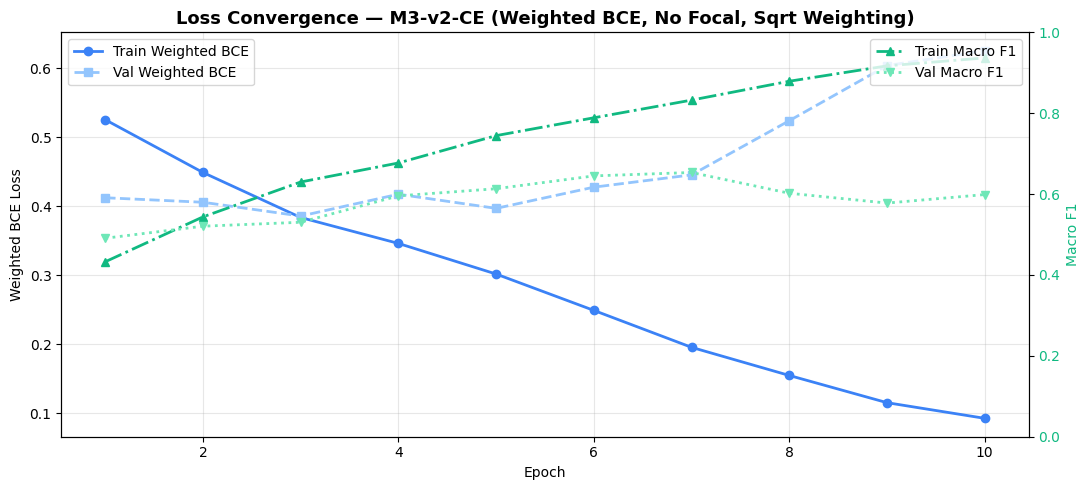

Saved: /kaggle/working/m3v2ce_loss_convergence.png


In [21]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(epochs_range, history['train_loss'], 'o-',  color='#3b82f6', label='Train Weighted BCE', lw=2)
ax1.plot(epochs_range, history['val_loss'],   's--', color='#93c5fd', label='Val Weighted BCE',   lw=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Weighted BCE Loss'); ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_range, history['train_f1'], '^-.',  color='#10b981', label='Train Macro F1', lw=2)
ax2.plot(epochs_range, history['val_f1'],   'v:',   color='#6ee7b7', label='Val Macro F1',   lw=2)
ax2.set_ylabel('Macro F1', color='#10b981')
ax2.tick_params(axis='y', labelcolor='#10b981')
ax2.set_ylim([0, 1]); ax2.legend(loc='upper right')

plt.title('Loss Convergence — M3-v2-CE (Weighted BCE, No Focal, Sqrt Weighting)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(LOSS_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOSS_PLOT_PATH}')

---
## Section 11: Evaluasi Test Set

In [22]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device)
print(f'Loaded best model from epoch {best_epoch}')

test_loss, test_m, test_true, test_pred = eval_epoch(
    model, test_loader, device, pos_weight
)

print('\n' + '='*65)
print('TEST SET RESULTS — M3-v2-CE (Weighted BCE, No Focal Loss)')
print('='*65)
print(f'Test Weighted BCE Loss : {test_loss:.4f}')
print(f'Accuracy  (Pers. 2.15) : {test_m["accuracy"]:.4f}')
print(f'Macro Precision        : {test_m["macro_prec"]:.4f}')
print(f'Macro Recall           : {test_m["macro_rec"]:.4f}')
print(f'Macro F1   (Pers. 2.14): {test_m["macro_f1"]:.4f}')

Loaded best model from epoch 7


Eval :   0%|          | 0/4 [00:00<?, ?it/s]


TEST SET RESULTS — M3-v2-CE (Weighted BCE, No Focal Loss)
Test Weighted BCE Loss : 0.3153
Accuracy  (Pers. 2.15) : 0.7705
Macro Precision        : 0.6948
Macro Recall           : 0.6720
Macro F1   (Pers. 2.14): 0.6771


In [23]:
per_asp = compute_per_aspect_metrics(test_true, test_pred)
avg_f1  = float(np.mean([r['f1'] for r in per_asp]))

print('\nPer-Aspect Results (sentiment-only, no_aspect excluded):')
print(f'{"Aspect":<14} {"F1":>8} {"Prec":>8} {"Rec":>8} {"Acc":>8} {"N":>5}')
print('-'*55)
for r in per_asp:
    print(f'{r["aspect"]:<14} {r["f1"]:>8.4f} {r["precision"]:>8.4f} '
          f'{r["recall"]:>8.4f} {r["accuracy"]:>8.4f} {r["n_active"]:>5}')
print('-'*55)
print(f'{"MACRO AVG":<14} {avg_f1:>8.4f}')


Per-Aspect Results (sentiment-only, no_aspect excluded):
Aspect               F1     Prec      Rec      Acc     N
-------------------------------------------------------
PIGMENTATION     0.7432   0.7167   0.8283   0.7941    34
LONGEVITY        0.4123   0.4000   0.4259   0.6429    14
TEXTURE          0.4621   0.4524   0.4725   0.7143    21
HYDRATION        0.5234   0.5111   0.5370   0.7619    42
PRICE            1.0000   1.0000   1.0000   1.0000    11
-------------------------------------------------------
MACRO AVG        0.6282


In [24]:
flat_true   = test_true.flatten()
flat_pred   = test_pred.flatten()
active_mask = flat_true != -1

print('Global Classification Report (active slots, 3-class):')
print(classification_report(
    flat_true[active_mask], flat_pred[active_mask],
    target_names=SENTIMENTS, digits=4, zero_division=0
))

# Per-class recall — key for ablation: does removing focal modulation hurt minority classes?
print('Per-class Recall (ablation — compare with M3-v2 focal version):')
for i, s in enumerate(SENTIMENTS):
    mask_cls = flat_true[active_mask] == i
    rec = (flat_pred[active_mask][mask_cls] == i).sum() / mask_cls.sum() if mask_cls.sum() > 0 else 0.0
    marker = ' ← minority (watch vs M3-v2)' if s in ['negative', 'neutral'] else ''
    print(f'  {s:<10}: {float(rec):.4f}{marker}')

Global Classification Report (active slots, 3-class):
              precision    recall  f1-score   support

    negative     0.6364    0.7500    0.6885        28
     neutral     0.6000    0.4286    0.5000        14
    positive     0.8481    0.8375    0.8428        80

    accuracy                         0.7705       122
   macro avg     0.6948    0.6720    0.6771       122
weighted avg     0.7710    0.7705    0.7680       122

Per-class Recall (ablation — compare with M3-v2 focal version):
  negative  : 0.7500 ← minority (watch vs M3-v2)
  neutral   : 0.4286 ← minority (watch vs M3-v2)
  positive  : 0.8375


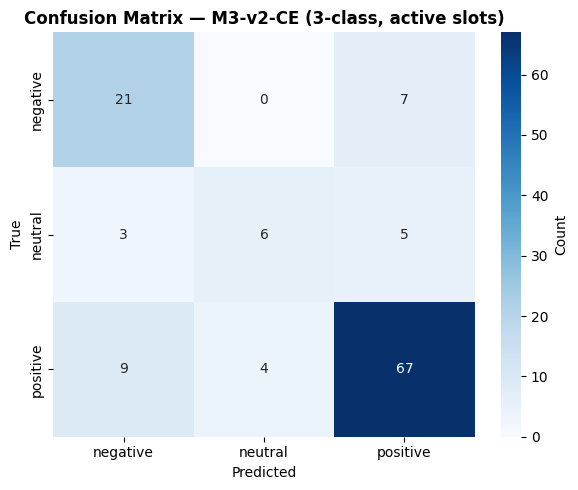

Saved: /kaggle/working/m3v2ce_confusion_matrix.png


In [25]:
cm = confusion_matrix(flat_true[active_mask], flat_pred[active_mask], labels=[0, 1, 2])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SENTIMENTS, yticklabels=SENTIMENTS,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — M3-v2-CE (3-class, active slots)', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(CM_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {CM_PLOT_PATH}')

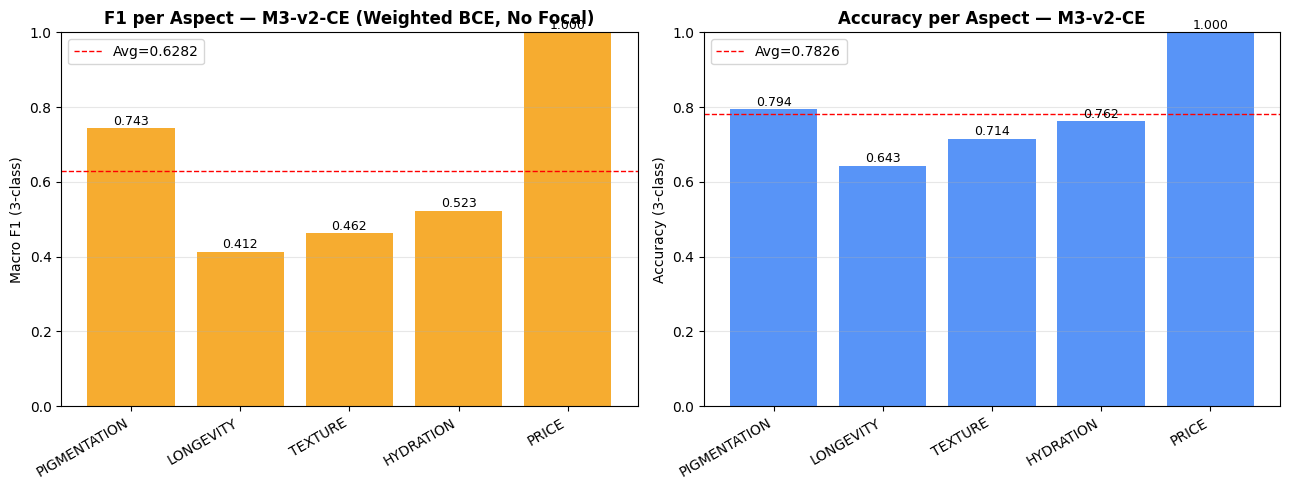

Saved: /kaggle/working/m3v2ce_per_aspect_results.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(ASPECTS))

for ax, vals, ylabel, color in zip(
        axes,
        [[r['f1'] for r in per_asp], [r['accuracy'] for r in per_asp]],
        ['Macro F1 (3-class)', 'Accuracy (3-class)'],
        ['#f59e0b', '#3b82f6']):
    bars = ax.bar(x, vals, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(ASPECTS, rotation=30, ha='right')
    ax.set_ylabel(ylabel); ax.set_ylim([0, 1])
    ax.axhline(np.mean(vals), color='red', linestyle='--', linewidth=1,
               label=f'Avg={np.mean(vals):.4f}')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

axes[0].set_title('F1 per Aspect — M3-v2-CE (Weighted BCE, No Focal)', fontweight='bold')
axes[1].set_title('Accuracy per Aspect — M3-v2-CE', fontweight='bold')
plt.tight_layout()
plt.savefig(PERASPECT_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PERASPECT_PLOT_PATH}')

---
## Section 12: Hamming Loss (Proposal Persamaan 2.16)

In [27]:
D = test_true.shape[0]
L = test_true.shape[1]

mismatches   = (test_true != test_pred).sum()
hamming_loss = mismatches / (D * L)

print('='*55)
print('HAMMING LOSS (Proposal Persamaan 2.16)')
print('='*55)
print(f'|D| (reviews) : {D}')
print(f'|L| (aspects) : {L}')
print(f'Mismatches    : {mismatches}')
print(f'Hamming Loss  : {mismatches}/{D*L} = {hamming_loss:.4f}')
print(f'Hamming Acc   : {1-hamming_loss:.4f}')

print('\nPer-Aspect Hamming Loss:')
print(f'{"Aspect":<14} {"Mismatch":>10} {"HL":>8} {"HA":>8}')
print('-'*44)
per_asp_hl = []
for i, asp in enumerate(ASPECTS):
    mm = int((test_true[:, i] != test_pred[:, i]).sum())
    hl = mm / D
    per_asp_hl.append(hl)
    print(f'{asp:<14} {mm:>10} {hl:>8.4f} {1-hl:>8.4f}')
print('-'*44)
print(f'{"MACRO AVG":<14} {"":>10} {np.mean(per_asp_hl):>8.4f} {1-np.mean(per_asp_hl):>8.4f}')

HAMMING LOSS (Proposal Persamaan 2.16)
|D| (reviews) : 50
|L| (aspects) : 5
Mismatches    : 28
Hamming Loss  : 28/250 = 0.1120
Hamming Acc   : 0.8880

Per-Aspect Hamming Loss:
Aspect           Mismatch       HL       HA
--------------------------------------------
PIGMENTATION            7   0.1400   0.8600
LONGEVITY               5   0.1000   0.9000
TEXTURE                 6   0.1200   0.8800
HYDRATION              10   0.2000   0.8000
PRICE                   0   0.0000   1.0000
--------------------------------------------
MACRO AVG                   0.1120   0.8880


---
## Section 13: Save Predictions & Metrics

In [28]:
# ── Predictions CSV ───────────────────────────────────────────────────────────
pred_rows = [
    {
        'review_id' : test_df.iloc[i]['review_id'],
        'aspect'    : asp,
        'true_label': ID2SENT.get(test_true[i, j], 'no_aspect'),
        'pred_label': ID2SENT.get(test_pred[i, j], 'no_aspect'),
        'correct'   : test_true[i, j] == test_pred[i, j],
    }
    for i in range(len(test_df))
    for j, asp in enumerate(ASPECTS)
]
pd.DataFrame(pred_rows).to_csv(PREDICTIONS_PATH, index=False)
print(f'Predictions saved: {PREDICTIONS_PATH}')

# ── Metrics JSON ──────────────────────────────────────────────────────────────
metrics_out = {
    'model'             : 'M3v2CE_CABiLSTM_IndoBERT_WeightedBCE_SqrtWeighting_NoFocal',
    'ablation_note'     : 'No Focal modulation — isolates contribution of class weighting alone',
    'config'            : CONFIG,
    'class_weights'     : {
        'strategy'      : 'sqrt_normalized',
        'reference'     : 'Mahajan et al. (2018)',
        'formula'       : 'sqrt(N_total / N_c), normalized to mean=1.0',
        'sent_counts'   : sent_counts,
        'total_sentiment': int(total_sent),
        'raw_weights'   : {s: float(w) for s, w in raw_weights.items()},
        'norm_weights'  : {s: float(w) for s, w in norm_weights.items()},
    },
    'focal_gamma'       : None,
    'best_epoch'        : int(best_epoch),
    'best_val_f1'       : float(best_val_f1),
    'test_loss'         : float(test_loss),
    'test_accuracy'     : float(test_m['accuracy']),
    'test_macro_f1'     : float(test_m['macro_f1']),
    'test_macro_prec'   : float(test_m['macro_prec']),
    'test_macro_rec'    : float(test_m['macro_rec']),
    'per_aspect'        : per_asp,
    'avg_per_aspect_f1' : float(avg_f1),
    'hamming_loss'      : {
        'formula'          : 'Proposal Persamaan 2.16',
        'D_reviews'        : int(D),
        'L_aspects'        : int(L),
        'overall'          : float(hamming_loss),
        'hamming_accuracy' : float(1 - hamming_loss),
        'per_aspect'       : {asp: float(hl) for asp, hl in zip(ASPECTS, per_asp_hl)},
    },
    'history': {k: [float(v) for v in vs] for k, vs in history.items()},
}
with open(METRICS_PATH, 'w') as f:
    json.dump(metrics_out, f, indent=2, default=str)
print(f'Metrics  saved: {METRICS_PATH}')

print('\n' + '='*55)
print(f'✅ M3-v2-CE complete — Test Macro F1: {test_m["macro_f1"]:.4f}')
print('='*55)

Predictions saved: /kaggle/working/m3v2ce_predictions.csv
Metrics  saved: /kaggle/working/m3v2ce_metrics.json

✅ M3-v2-CE complete — Test Macro F1: 0.6771
